<a href="https://colab.research.google.com/github/cristianzucconi2-web/deep_learning/blob/main/Llama_3_2_3B_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install unsloth
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

from unsloth import FastLanguageModel
import torch
import pandas as pd
from datasets import Dataset

# Carichiamo il modello 3B (il migliore per il tuo caso)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct",
    max_seq_length = 2048,
    load_in_4bit = True,
)

# Aggiungiamo i "sensori" per il Fine-Tuning (LoRA)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, #rango, quantità di memoria nuova che do al modello per imparare l'ironia, più il rango è alto più parametri aggiungo
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"], #in llama 3.2 concentarre l'addestarmento solo sui moduli di attention (q,k,v,o), rende il modello più stabile per compiti di classificazione
    lora_alpha = 16, # peso dell'addestramento, uno ad uno con r
    lora_dropout = 0, # lora_dropout serve a evitare che il modello impari a memoria il dataset (overfitting)
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.9/402.9 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 132.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.3.11 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


In [ ]:
# Scarichiamo il repository GitHub per avere i file sottomano
!git clone https://github.com/Cyvhee/SemEval2018-Task3.git
print("Cartelle scaricate! Ora controlliamo cosa c'è in train.")

Cloning into 'SemEval2018-Task3'...
remote: Enumerating objects: 315, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 315 (delta 0), reused 0 (delta 0), pack-reused 312 (from 1)
Receiving objects: 100% (315/315), 681.37 KiB | 2.64 MiB/s, done.
Resolving deltas: 100% (142/142), done.
Cartelle scaricate! Ora controlliamo cosa c'è in train.


In [ ]:
import pandas as pd
import re
from datasets import Dataset

# Percorso basato sul nuovo repository di Cynthia
path_train = 'SemEval2018-Task3/datasets/train/SemEval2018-T3-train-taskA_emoji.txt'

try:
    # Carichiamo il file (Tab Separated)
    df = pd.read_csv(path_train, sep='\t')
    # Se il file non ha header, forziamo i nomi delle colonne
    if 'tweet text' not in df.columns:
        df = pd.read_csv(path_train, sep='\t', header=None, names=['index', 'label', 'tweet text'])

    print(f" Dataset caricato con successo! Righe: {len(df)}")
except Exception as e:
    print(f" Errore: Assicurati che il file sia in quel percorso. Errore: {e}")

# Pulizia per eliminare il rumore (Link e @User)
def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # rimuovi i link
    text = re.sub(r'@\w+', '', text) # rimuovi i tag dagli utenti
    return text.strip()

df['tweet text'] = df['tweet text'].apply(clean_tweet)

# Formattazione Prompt per Llama 3 (Lo specializziamo come esperto)
def format_instruct(row):
    return f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n" \
           f"You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|eot_id|>" \
           f"<|start_header_id|>user<|end_header_id|>\n\n" \
           f"Tweet: {row['tweet text']}<|eot_id|>" \
           f"<|start_header_id|>assistant<|end_header_id|>\n\n" \
           f"{row['label']}<|eot_id|>"

df['formatted_text'] = df.apply(format_instruct, axis=1) # crea una nuova colonna chiamata formatted_text che contiene l'intera conversazione pronta
dataset = Dataset.from_pandas(df[['formatted_text']]) # trasforma tutto in un formato leggibile dalla scheda video

print(f"✅ Dataset pronto per l'addestramento! Numero esempi: {len(dataset)}")

✅ Dataset caricato con successo! Righe: 3818
✅ Dataset pronto per l'addestramento! Numero esempi: 3818


In [ ]:
# Rimuoviamo la prima riga che contiene solo i nomi delle colonne
df_clean = df.iloc[1:].copy()

# Rifacciamo la formattazione solo sui dati veri
def format_instruct_final(row):
    return f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n" \
           f"You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|eot_id|>" \
           f"<|start_header_id|>user<|end_header_id|>\n\n" \
           f"Tweet: {row['tweet text']}<|eot_id|>" \
           f"<|start_header_id|>assistant<|end_header_id|>\n\n" \
           f"{row['label']}<|eot_id|>"  # <|eot_id|> (End Of Turn), separatrore che dice è finito il mio turno
                                        # mettp anche label perché gli passo la risposta
df_clean['formatted_text'] = df_clean.apply(format_instruct_final, axis=1)  # ora ha una colonna dove domanda e risposta sono scritte insieme

# Aggiorniamo il dataset per Unsloth
dataset = Dataset.from_pandas(df_clean[['formatted_text']])  #Il modello Llama non sa leggere i "DataFrame" di Pandas (quelli che sembrano tabelle Excel). Ha bisogno di un formato speciale chiamato Dataset (della libreria Hugging Face)

print(f"✅ Dataset ripulito! Righe reali: {len(dataset)}")
print("-" * 30)
print("Controllo Esempio 1 (deve essere vero ora):")
print(dataset[0]['formatted_text'])

✅ Dataset ripulito! Righe reali: 3817
------------------------------
Controllo Esempio 1 (deve essere vero ora):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|eot_id|><|start_header_id|>user<|end_header_id|>

Tweet: Sweet United Nations video. Just in time for Christmas. #imagine #NoReligion<|eot_id|><|start_header_id|>assistant<|end_header_id|>

1<|eot_id|>


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

# Questa volta restituiamo una lista, come richiesto dal ValueError
def formatting_prompts_func(examples):
    return [text for text in examples["formatted_text"]]

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "formatted_text", # indica esplicitamente al trainer dove leggere i tweet pronti
    formatting_func = formatting_prompts_func,
    max_seq_length = 2048,
    dataset_num_proc = 2, # sfrutta il multi-processing per velocizzare il caricamento dei dati, rendendo l'avvio del training quasi istantaneo
    args = TrainingArguments(
        per_device_train_batch_size = 4, #il modello vede 4 tweet alla volta,
        gradient_accumulation_steps = 4, #ma non aggiorna subito i suoi pesi. Aspetta di averne visti 16 (4x4)
        warmup_steps = 5,
        num_train_epochs = 3, # Obiettivo 80%
        learning_rate = 2e-4, # la velocità con cui il modello cambia idea
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit", # uso una versione compressa dell'ottimizzatore (AdamW).
        weight_decay = 0.01, # la penalità serve a non fare overfitting che ripete a memoria il dataset
        lr_scheduler_type = "linear",
        seed = 3407, # per avere dati replicabili
        output_dir = "outputs",
        report_to = "none",
    ),
)

# ORA LANCIA IL TRAINING
print("Terzo tentativo")
trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/3817 [00:00<?, ? examples/s]

Terzo tentativo (quello buono). Se vedi la tabella, ci siamo!


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,817 | Num Epochs = 3 | Total steps = 717
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 9,175,040 of 3,221,924,864 (0.28% trained)


Step,Training Loss
1,4.761766
2,4.875010
3,4.586677
4,4.804124
5,4.555527
6,4.404832
7,4.076846
8,3.893291
9,3.531151
10,3.483718


In [ ]:
import pandas as pd
import re
import torch
from tqdm import tqdm

# 1. Carichiamo il file di test (Gold Standard)
path_test = 'SemEval2018-Task3/datasets/goldtest_TaskA/SemEval2018-T3_gold_test_taskA_emoji.txt'
test_df = pd.read_csv(path_test, sep='\t')

if 'tweet text' not in test_df.columns:
    test_df = pd.read_csv(path_test, sep='\t', header=None, names=['index', 'label', 'tweet text'])

# Pulizia
def clean_test(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    return text.strip()

test_df['tweet text'] = test_df['tweet text'].apply(clean_test)

# model.eval() è lo standard di PyTorch per l'inferenza
model.eval() #Comunichi a PyTorch che il training è finito. Disattiva funzioni come il Dropout che servono solo durante l'apprendimento.

predictions = []
print(f"Analisi di {len(test_df)} tweet in corso (modalità compatibile)...")

# Disabilitiamo il calcolo dei gradienti per risparmiare memoria e andare veloci
with torch.no_grad():
    for text in tqdm(test_df['tweet text']):
        prompt = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n" \
                 f"You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|eot_id|>" \
                 f"<|start_header_id|>user<|end_header_id|>\n\n" \
                 f"Tweet: {text}<|eot_id|>" \
                 f"<|start_header_id|>assistant<|end_header_id|>\n\n"

        inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")

        # Usiamo il metodo standard generate
        outputs = model.generate(
            **inputs,
            max_new_tokens = 1, # Ci serve solo un carattere (0 o 1)
            use_cache = True, #A differenza di Phi-3.5, Llama 3.2 gestisce bene la cache su Colab, quindi la attiviamo per velocizzare il processo.
            pad_token_id = tokenizer.eos_token_id,
            temperature = 0.01, # Lo vogliamo quasi deterministico
            do_sample = False
        )

        response = tokenizer.batch_decode(outputs)[0]

        # Estraiamo la risposta finale
        try:
            answer_part = response.split("<|start_header_id|>assistant<|end_header_id|>\n\n")[-1]  #Il modello restituisce tutto il testo (domanda + risposta). Con lo split tagli via la domanda e tieni solo l'ultima parte, ovvero quello che ha scritto l'assistente.
            digit = re.search(r'[01]', answer_part).group()
            predictions.append(int(digit))
        except:
            predictions.append(0)  # metto su prediction

test_df['prediction'] = predictions
print("\n✅ Analisi completata!")

Analisi di 785 tweet in corso (modalità compatibile)...


  0%|          | 0/785 [00:00<?, ?it/s]Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, Fu


✅ Analisi completata!


======= RISULTATI FINALI (PULITI) =======
ACCURACY TOTALE: 84.82%

REPORT DETTAGLIATO:
              precision    recall  f1-score   support

 Non Ironico       0.94      0.80      0.86       473
     Ironico       0.75      0.92      0.83       311

    accuracy                           0.85       784
   macro avg       0.84      0.86      0.85       784
weighted avg       0.86      0.85      0.85       784



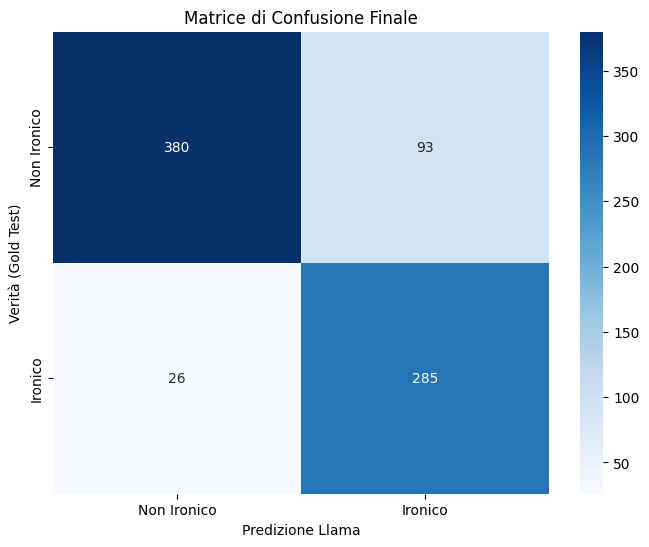

In [ ]:
# 1. Rimuoviamo la riga che contiene la stringa 'Label'
# Cerchiamo solo le righe dove la label è effettivamente '0' o '1'
test_df_clean = test_df[test_df['label'].astype(str).str.contains('0|1')].copy() # come per l'addestramento, anche elimino eventuali righe spazzatura

# 2. Ora convertiamo in interi senza errori
y_true = test_df_clean['label'].astype(int)  # trasforma tutto in numeri interi per permettere alla libreria sklearn di fare i calcoli matematici di confronto.
y_pred = test_df_clean['prediction']

# 3. Calcolo dei parametri finali
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=['Non Ironico', 'Ironico'])

print("======= RISULTATI FINALI (PULITI) =======")
print(f"ACCURACY TOTALE: {accuracy:.2%}")
print("\nREPORT DETTAGLIATO:")
print(report)

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Ironico', 'Ironico'],
            yticklabels=['Non Ironico', 'Ironico'])
plt.xlabel('Predizione Llama')
plt.ylabel('Verità (Gold Test)')
plt.title('Matrice di Confusione Finale')
plt.show()

In [ ]:
def test_veloce(tweet_italiano):
    prompt = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n" \
             f"You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|eot_id|>" \
             f"<|start_header_id|>user<|end_header_id|>\n\n" \
             f"Tweet: {tweet_italiano}<|eot_id|>" \
             f"<|start_header_id|>assistant<|end_header_id|>\n\n"

    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens = 1, temperature=0.01)
    risultato = tokenizer.batch_decode(outputs)[0].split("assistant<|end_header_id|>\n\n")[-1][0]

    label = "IRONICO (1)" if risultato == "1" else "NON IRONICO (0)"
    print(f"Tweet: {tweet_italiano} -> Sentenza: {label}")

# Testalo con queste due:
test_veloce("Amo tantissimo quando il treno ha 60 minuti di ritardo e io ho una riunione importante.")
test_veloce("Oggi c'è un sole bellissimo e sono felice di andare al mare.")
test_veloce("Mi piace tanto andare al parco")
test_veloce("Bello perdere una finale al 90esimo, proprio un sogno")

Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=1)

Tweet: Amo tantissimo quando il treno ha 60 minuti di ritardo e io ho una riunione importante. -> Sentenza: IRONICO (1)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: Oggi c'è un sole bellissimo e sono felice di andare al mare. -> Sentenza: NON IRONICO (0)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: Mi piace tanto andare al parco -> Sentenza: NON IRONICO (0)
Tweet: Bello perdere una finale al 90esimo, proprio un sogno -> Sentenza: IRONICO (1)


In [ ]:
def test_zero_shot(tweet_italiano):
    prompt = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n" \
             f"You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|eot_id|>" \
             f"<|start_header_id|>user<|end_header_id|>\n\n" \
             f"Tweet: {tweet_italiano}<|eot_id|>" \
             f"<|start_header_id|>assistant<|end_header_id|>\n\n"

    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")
    # Generiamo la risposta col modello base
    outputs = model.generate(**inputs, max_new_tokens = 1, temperature=0.01)
    risultato = tokenizer.batch_decode(outputs)[0].split("assistant<|end_header_id|>\n\n")[-1][0]

    label = "IRONICO (1)" if risultato == "1" else "NON IRONICO (0)"
    print(f"Tweet: {tweet_italiano} -> Sentenza Zero-Shot: {label}")

test_sentences_v2 = [
    # --- IRONICHE (1) ---
    "Splendid! My computer crashed right before I saved my 20-page report.",
    "I'm so thrilled to be stuck in a traffic jam for two hours. Best day ever!",
    "Wow, a flat tire on my way to a job interview. My luck is just incredible.",
    "Brilliant! The coffee machine is broken and it's Monday morning. Just perfect.",
    "I absolutely adore it when people talk loudly in the movie theater. So polite!",

    # --- NON IRONICHE (0) ---
    "I'm happy that I finally passed my driving test.",
    "It was a very long day, but I feel satisfied with what I achieved. So good",
    "The garden looks lovely now that all the flowers are blooming.",
    "the food was delicious, i reccomand it.",
    "The teacher explained the topic clearly and I understood everything."
]

print("--- SECONDO TEST COMPARATIVO (10 NUOVE FRASI) ---")
for sentence in test_sentences_v2:
    test_zero_shot(sentence)

    test_sentences_v3 = [
    # --- IRONICHE (1) ---
    "Great, my computer decided to update right when I started my presentation.",
    "I love it when people park so close that I can't even open my car door.",
    "I'm so thrilled that my neighbor started playing the drums at 2 AM.",

    # --- NON IRONICHE (0) ---
    "I finished the project and I can relax for the weekend.",
    "I'm not feeling ok today",
    "I love that garden",
]

print("--- TERZO TEST COMPARATIVO (LA SFIDA FINALE) ---")
for sentence in test_sentences_v3:
    test_zero_shot(sentence)

Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- SECONDO TEST COMPARATIVO (10 NUOVE FRASI) ---


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: Splendid! My computer crashed right before I saved my 20-page report. -> Sentenza Zero-Shot: IRONICO (1)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Tweet: I love it when people park so close that I can't even open my car door. -> Sentenza Zero-Shot: IRONICO (1)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: I'm so thrilled that my neighbor started playing the drums at 2 AM. -> Sentenza Zero-Shot: IRONICO (1)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: I finished the project and I can relax for the weekend. -> Sentenza Zero-Shot: NON IRONICO (0)
Tweet: I'm not feeling ok today -> Sentenza Zero-Shot: NON IRONICO (0)
Tweet: I love that garden -> Sentenza Zero-Shot: IRONICO (1)


In [ ]:
def test_balanced_model(tweet_test):
    # Nuovo System Prompt più prudente
    prompt = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n" \
             f"You are a balanced linguistic expert. Be careful: not every positive word is irony. " \
             f"Only answer 1 if you are sure there is a logical contradiction. Answer ONLY with 1 or 0.<|eot_id|>" \
             f"<|start_header_id|>user<|end_header_id|>\n\n" \
             f"Tweet: {tweet_test}<|eot_id|>" \
             f"<|start_header_id|>assistant<|end_header_id|>\n\n"

    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens = 1, temperature=0.01)
    risultato = tokenizer.batch_decode(outputs)[0].split("assistant<|end_header_id|>\n\n")[-1][0]

    label = "IRONICO (1)" if risultato == "1" else "NON IRONICO (0)"
    print(f"Tweet: {tweet_test} -> Sentenza Bilanciata: {label}")

# Testiamo i casi critici di prima
print("--- TEST CON SYSTEM PROMPT BILANCIATO ---")
test_balanced_model("I love that garden")
test_balanced_model("I'm happy that I finally passed my driving test")
test_balanced_model("I love spending my entire Saturday cleaning the house. So much fun!")
test_balanced_model("I love losing after so much training")

Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- TEST CON SYSTEM PROMPT BILANCIATO ---


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: I love that garden -> Sentenza Bilanciata: NON IRONICO (0)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: I'm happy that I finally passed my driving test -> Sentenza Bilanciata: IRONICO (1)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: I love spending my entire Saturday cleaning the house. So much fun! -> Sentenza Bilanciata: IRONICO (1)
Tweet: I love losing after so much training -> Sentenza Bilanciata: IRONICO (1)


In [ ]:
def test_balanced_final(tweet_text):
    # Il prompt "bilanciato" che abbiamo studiato
    prompt = f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n" \
             f"You are a balanced linguistic expert. Be careful: not every positive word is irony. " \
             f"Only answer 1 if you are sure there is a logical contradiction. Answer ONLY with 1 or 0.<|eot_id|>" \
             f"<|start_header_id|>user<|end_header_id|>\n\n" \
             f"Tweet: {tweet_text}<|eot_id|>" \
             f"<|start_header_id|>assistant<|end_header_id|>\n\n"

    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens = 1, temperature=0.01)
    risultato = tokenizer.batch_decode(outputs)[0].split("assistant<|end_header_id|>\n\n")[-1][0]

    label = "IRONICO (1)" if risultato == "1" else "NON IRONICO (0)"
    print(f"Tweet: {tweet_text} -> Sentenza: {label}")

# --- LISTA COMPLETA 5+5 ---
test_sentences_final = [
    # IRONICHE (Contraddizioni forti)
    "Splendid! My computer crashed right before I saved my 20-page report.",
    "I'm so thrilled to be stuck in a traffic jam for two hours. Best day ever!",
    "Wow, a flat tire on my way to a job interview. My luck is just incredible.",
    "Brilliant! The coffee machine is broken and it's Monday morning.",
    "I'm so thrilled that my neighbor started playing the drums at 2 AM.",

    # NON IRONICHE (Sincere)
    "I'm happy that I finally passed my driving test.",
    "It was a very long day, but I feel satisfied with what I achieved. So good",
    "The garden looks lovely now that all the flowers are blooming.",
    "the food was delicious, i reccomand it.",
    "I finished the project and I can relax for the weekend."
]

print("--- TEST FINALE COL PROMPT BILANCIATO (5+5) ---")
for sentence in test_sentences_final:
    test_balanced_final(sentence)

Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- TEST FINALE COL PROMPT BILANCIATO (5+5) ---


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: Splendid! My computer crashed right before I saved my 20-page report. -> Sentenza: IRONICO (1)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Tweet: It was a very long day, but I feel satisfied with what I achieved. So good -> Sentenza: NON IRONICO (0)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: The garden looks lovely now that all the flowers are blooming. -> Sentenza: NON IRONICO (0)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: the food was delicious, i reccomand it. -> Sentenza: NON IRONICO (0)
Tweet: I finished the project and I can relax for the weekend. -> Sentenza: NON IRONICO (0)


In [ ]:
from google.colab import drive

drive.mount('/content/drive')



# Definiamo il percorso finale

save_path = "/content/drive/MyDrive/Llama3_Ironic_Detector_Final"



# Salvataggio dei pesi addestrati (LoRA adapters)

model.save_pretrained(save_path)

tokenizer.save_pretrained(save_path)



print(f"✅ Tutto salvato nel tuo Drive in: {save_path}")


Mounted at /content/drive
✅ Tutto salvato nel tuo Drive in: /content/drive/MyDrive/Llama3_Ironic_Detector_Final
Ora puoi chiudere Colab senza perdere il tuo lavoro!
